# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset:  https://www.kaggle.com/datasets/udaymalviya/bank-loan-data/data

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [ ]:
# Brief explanation of my business issue.
For this analysis, I am using a bank loan dataset that contains information about loan characteristics and loan repayment status 
along with the borrower's information. 
The dataset includes variables such as loan status, income, credit score, home ownership, and 
other indicators that help assess repayment capacity and default risk.

In [1]:
# Importing libraries such as numpy, pandas, seaborn, and matplotlib.
# Import numpy for numerical operations.
import numpy as np 

# Import pandas to create a Dataframe.
import pandas as pd

# Import matplotlib for basic data visualizations.
import matplotlib.pyplot as plt

# Import seaborn for more advanced statistical visualizations
import seaborn as sns

#Loading the Loan dataset into a pandas Dataframe.
loan_data = pd.read_csv("loan_data.csv")

# Displaying rows to understand data structure.
loan_data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
loan_data = pd.read_csv("loan_data.csv")

# Summary of the column names, data types, and non-null counts
loan_data.info()

# Generate descriptive statistics for numerical columns
loan_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
# Calculate the total loan amount issued by the bank. This is an important KPI  to calculate 
# a bank’s total exposure to credit risk and helps further to
# compare how much of this total amount is tied to good loans
# versus bad or defaulted loans.

loan_data['loan_amnt'].sum()

431242090.0

In [7]:
# Check for the good loan vs. the bad loan out of the Total loan amount.

loan_data['loan_status_label'] = loan_data['loan_status'].map({0: 'Bad Loan', 1: 'Good Loan'})
bad_loan_total = loan_data[loan_data['loan_status'] == 0]['loan_amnt'].sum()
good_loan_total = loan_data[loan_data['loan_status'] == 1]['loan_amnt'].sum()
print("Bad Loan Total:", bad_loan_total)
print("Good Loan Total:", good_loan_total)

Bad Loan Total: 322685192.0
Good Loan Total: 108556898.0


In [9]:
# Understand the distribution of home ownership statuses
# Helps to analyze how housing status may relate
# to loan repayment and default risk

loan_data['person_home_ownership'].value_counts()

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

In [11]:
# Understand the Distribution of loan purposes across the dataset.
# Helps understand the reason why the loan was borrowed in the first place.
# examine whether certain loan purposes are associated with default risk and 
# to assess how loan intent may impact repayment capacity.

loan_data['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [13]:
# Helps understand the distribution of Loan status. 
# This is a crucial KPI that helps categorize good and bad loans.
# Further, I will be using this as an important variable in my data analysis to compare against other 
#columns with borrowers' characteristics to help understand the impact on repaying capacity and default risk.

loan_data['loan_intent'].value_counts()

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

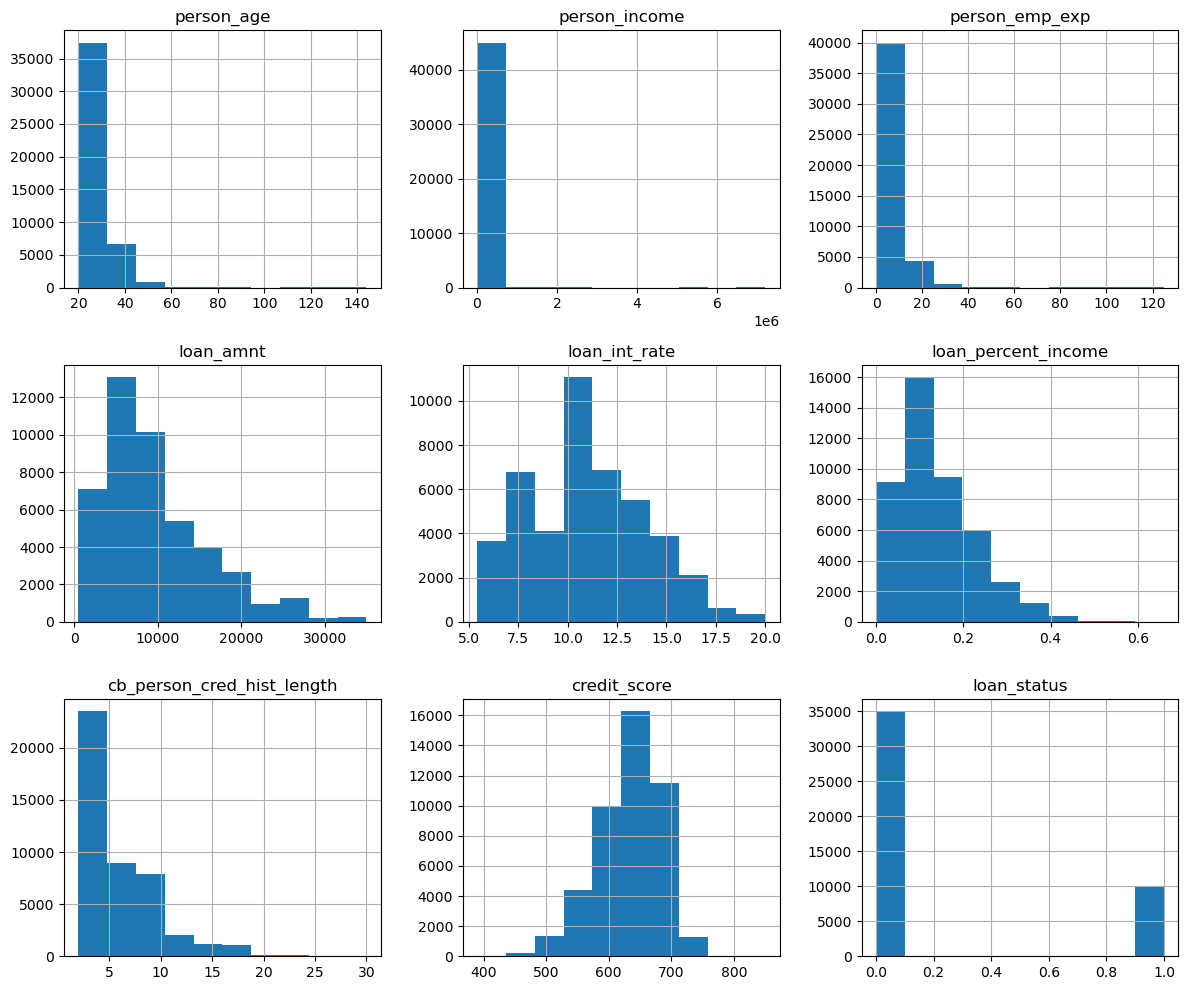

In [15]:
# Generate histograms for all numerical variables in the dataset.
# Helps figure out outliers and potential data quality issues
# Helps determine what further cleaning may be required before deeper analysis.

loan_data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

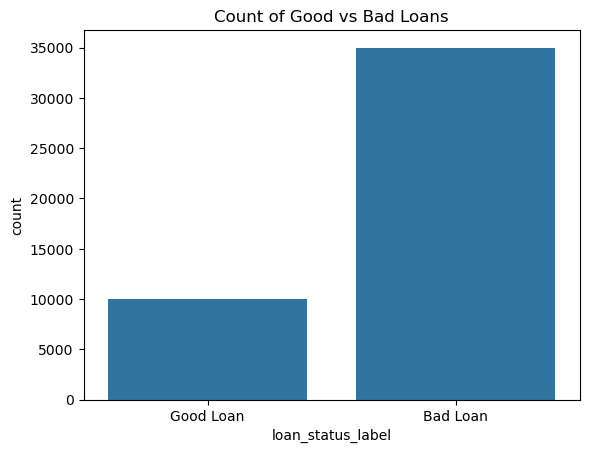

In [17]:
# Visualizing Good and Bad loans for better visibility
loan_data['loan_status_label'] = loan_data['loan_status'].map({0: 'Bad Loan', 1: 'Good Loan'})

sns.countplot(data=loan_data, x='loan_status_label')
plt.title('Count of Good vs Bad Loans')
plt.show()

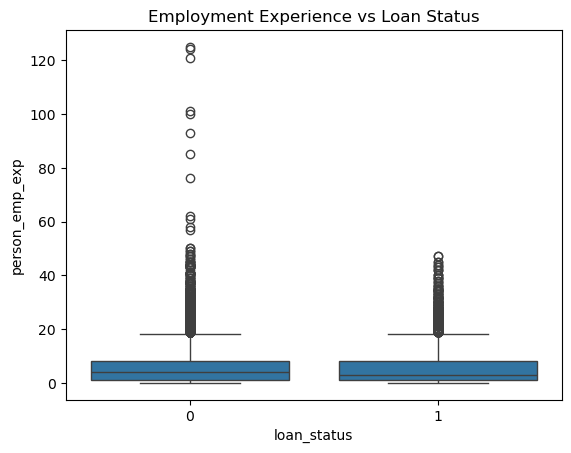

In [31]:
sns.boxplot(x='loan_status', y='person_emp_exp', data=loan_data)
plt.title("Employment Experience vs Loan Status")
plt.show()

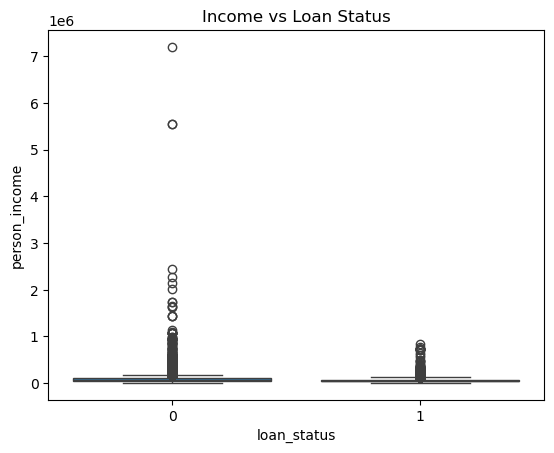

In [29]:
# Create a box plot to examine the relationship between the borrower's income
# and loan status. Understanding this relationship helps assess whether income level
# is associated with repayment capacity and default risk. This visualization helps in notifying differences
# in median income, spread, also helps to identify the presence of outliers.

sns.boxplot(x='loan_status', y='person_income', data=loan_data)
plt.title("Income vs Loan Status")
plt.show()

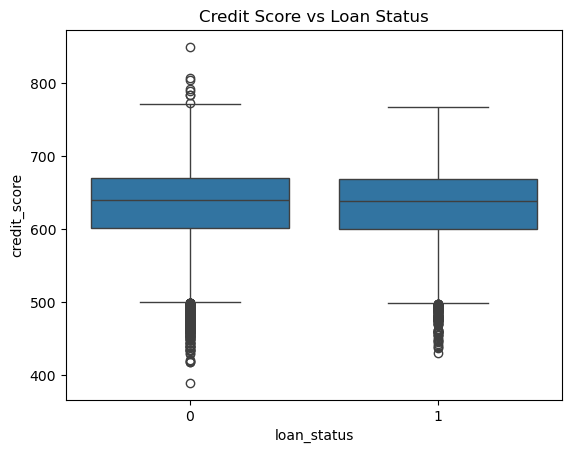

In [27]:
# Create a box plot to analyze the relationship between credit score
# and loan status. This visualization compares the distribution of
# credit scores for good loans versus bad loans, highlighting
# differences in median values, variability, and outliers.
# Credit score is a key indicator of a borrower’s creditworthiness,
# and this analysis helps assess its impact on repayment capacity
# and default risk.

sns.boxplot(x='loan_status', y='credit_score', data=loan_data)
plt.title("Credit Score vs Loan Status")
plt.show()

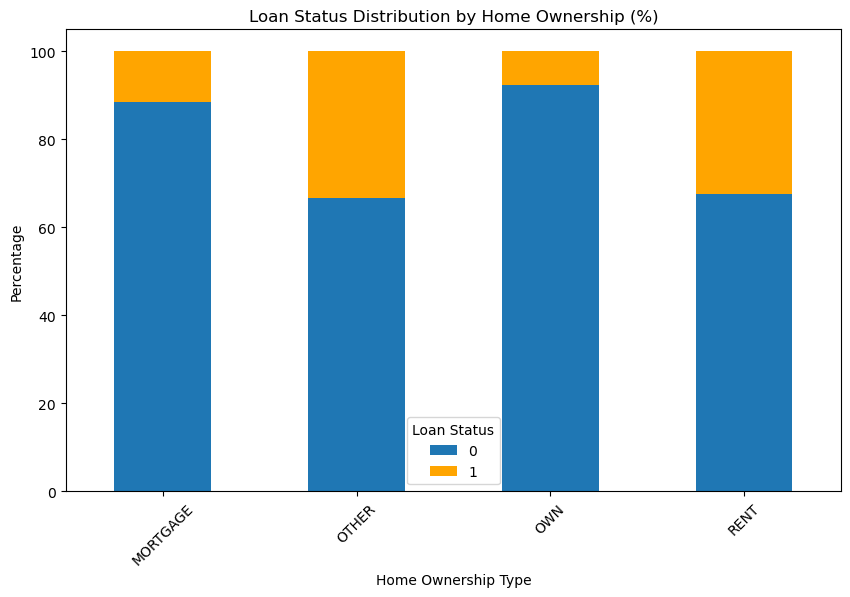

In [25]:
# Calculate the percentage distribution of loan status by home ownership type.
# Grouping by 'person_home_ownership' and 'loan_status' allows us to see
# how repayment outcomes differ across housing categories.


percent_table = loan_data.groupby('person_home_ownership')['loan_status'] \
                         .value_counts(normalize=True) \
                         .unstack() * 100

percent_table

colors = ['C0', 'orange'] 

percent_table.plot(kind='bar', stacked=True, figsize=(10,6), color=colors)

plt.ylabel("Percentage")
plt.xlabel("Home Ownership Type")
plt.title("Loan Status Distribution by Home Ownership (%)")
plt.legend(title="Loan Status")
plt.xticks(rotation=45)
plt.show()

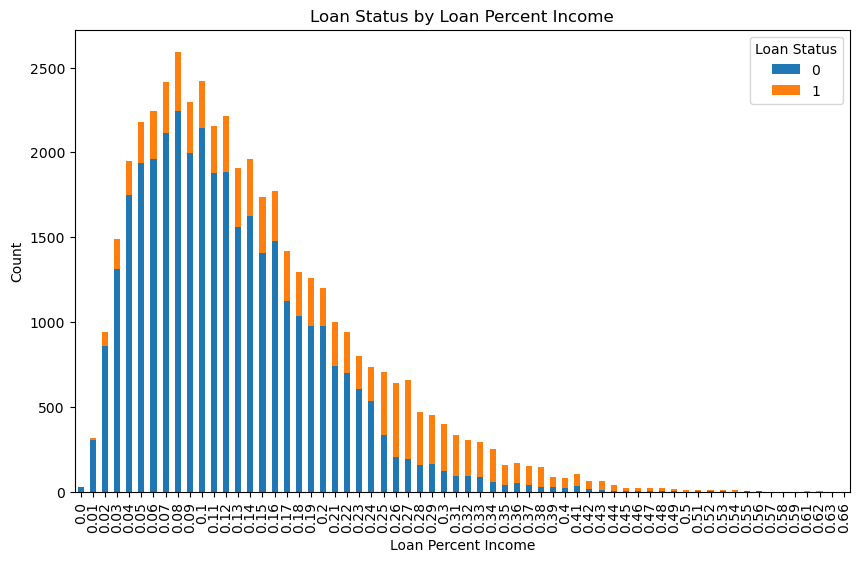

In [23]:
# Visualize the cross-tabulated data using a stacked bar chart
# A stacked bar chart makes it easier to compare the proportion
# of good vs bad loans across different loan percent income levels
# and assess whether higher ratios are associated with higher defaults.

import pandas as pd
import matplotlib.pyplot as plt
loan_data = pd.read_csv("loan_data.csv")
ct = pd.crosstab(loan_data['loan_percent_income'], loan_data['loan_status'])

ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Count")
plt.xlabel("Loan Percent Income")
plt.title("Loan Status by Loan Percent Income")
plt.legend(title="Loan Status")
plt.show()

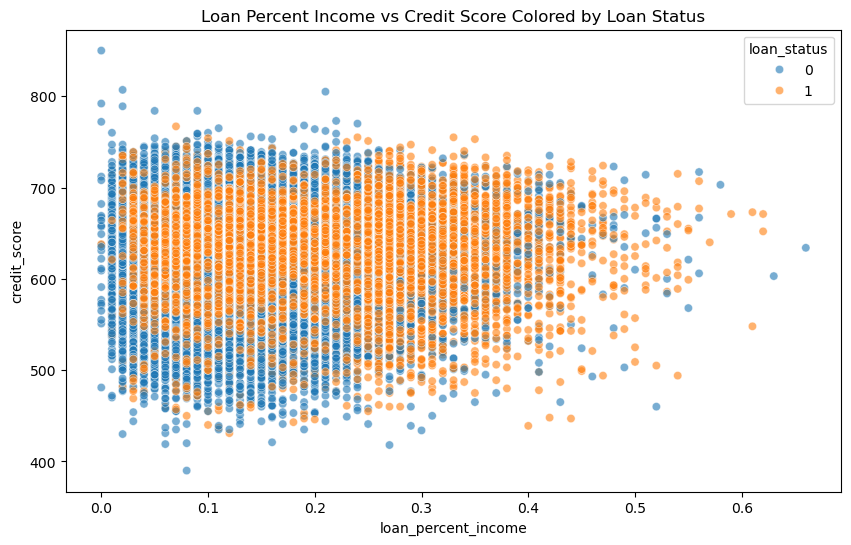

In [21]:
# Create a scatter plot to examine the relationship between
# loan percent of income and credit score, colored by loan status.
# This visualization allows us to analyze how
# their combined effect relates to loan repayment outcomes.

import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=loan_data,
    x='loan_percent_income',
    y='credit_score',
    hue='loan_status',
    alpha=0.6
)
plt.title("Loan Percent Income vs Credit Score Colored by Loan Status")
plt.show()

<Axes: xlabel='previous_loan_defaults_on_file', ylabel='count'>

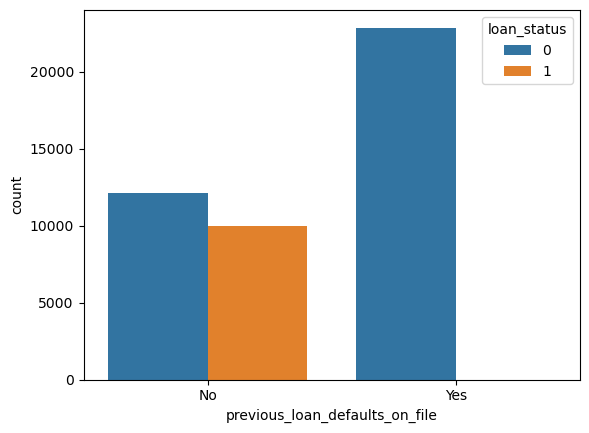

In [19]:
# Create a count plot to analyze the relationship between
# previous loan defaults and current loan status.
# This visualization helps assess whether a borrower’s history
# of past defaults is associated as a key indicator of repayment risk.

sns.countplot(data=loan_data, x='previous_loan_defaults_on_file', hue='loan_status')

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset?
   There were no duplicates or missing values.
   
2. Do you have any concerns about your dataset?
   I want to drop some columns that I will not be needing in my analysis. There are outliers in columns that I will be using in my analysis.
   
3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data?
   I want to rename some columns. I want to change the loan status numeric values to string types: 'Paid' and 'Default'. I want to categorize credit score numeric values into string types Poor, Fair, and Good based on credit score range.